# 分别使用男女足数据训练的 xG 模型

这个 notebook 用 `statsbombpy.sb.competition_events(...)` 重新实现
`enriched_xg_features.ipynb` 里的事件加载逻辑。

主比较会用女足训练集训练一个 xG 模型，再从男足 full set 里随机下采样出和女足训练集一样多的射门来训练另一个 xG 模型。然后让两个模型都给同一批女足测试集射门打分，比较射门级 xG、球员级 xG 排名，以及它们和 StatsBomb 自带 `shot_statsbomb_xg` 的关系。

男足 full set 模型仍会训练，但只作为补充诊断，用来观察男足数据量更多这件事本身会带来多大影响。这个 xG 模型使用的特征包括：距离、角度、身体部位、射门技术、射门类型、进攻模式 / 定位球上下文、是否受压迫，以及是否 first-time shot。

## 1. 导入dependency和设置constant variables

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np
import pandas as pd
from scipy import stats
from statsbombpy import sb
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

print("ready")


ready


## 2. 比赛列表

每个条目同时包含两类信息：一类是 `sb.matches(...)` 使用的
`competition_id` / `season_id`，另一类是 `sb.competition_events(...)` 使用的
`country` / `division` / `season` / `gender` 字符串。

In [2]:
WOMEN_COMPETITIONS = [
    {
        "competition_id": 37,
        "season_id": 281,
        "country": "England",
        "division": "FA Women's Super League",
        "season": "2023/2024",
        "gender": "female",
        "league": "WSL",
    },
    {
        "competition_id": 135,
        "season_id": 281,
        "country": "Germany",
        "division": "Frauen Bundesliga",
        "season": "2023/2024",
        "gender": "female",
        "league": "Frauen Bundesliga",
    },
    {
        "competition_id": 182,
        "season_id": 281,
        "country": "Spain",
        "division": "Liga F",
        "season": "2023/2024",
        "gender": "female",
        "league": "Liga F",
    },
    {
        "competition_id": 131,
        "season_id": 281,
        "country": "Italy",
        "division": "Serie A Women",
        "season": "2023/2024",
        "gender": "female",
        "league": "Serie A Women",
    },
    {
        "competition_id": 49,
        "season_id": 107,
        "country": "United States of America",
        "division": "NWSL",
        "season": "2023",
        "gender": "female",
        "league": "NWSL",
    },
]

MEN_COMPETITIONS = [
    {
        "competition_id": 11,
        "season_id": 27,
        "country": "Spain",
        "division": "La Liga",
        "season": "2015/2016",
        "gender": "male",
        "league": "La Liga",
    },
    {
        "competition_id": 2,
        "season_id": 27,
        "country": "England",
        "division": "Premier League",
        "season": "2015/2016",
        "gender": "male",
        "league": "Premier League",
    },
    {
        "competition_id": 12,
        "season_id": 27,
        "country": "Italy",
        "division": "Serie A",
        "season": "2015/2016",
        "gender": "male",
        "league": "Serie A",
    },
    {
        "competition_id": 7,
        "season_id": 27,
        "country": "France",
        "division": "Ligue 1",
        "season": "2015/2016",
        "gender": "male",
        "league": "Ligue 1",
    },
]


## 3. 加载比赛数据

这里仍然需要 match list，因为我们要基于女足比赛做 game-level 的训练 / 测试集切分。
后面加载事件数据时会使用 `sb.competition_events(...)`，而不是手动逐场调用
`sb.events(match_id=...)`。

In [3]:
def load_remote_matches(competitions, cache_tag):
    """Load remote StatsBomb match lists for a set of competitions."""
    matches_cache = CACHE_DIR / f"{cache_tag}_matches_competition_events_method.pkl"
    if matches_cache.exists():
        print(f"[cache] {cache_tag} matches")
        return pd.read_pickle(matches_cache)

    match_frames = []
    for competition in competitions:
        try:
            matches = sb.matches(
                competition_id=competition["competition_id"],
                season_id=competition["season_id"],
            )
        except Exception as error:
            print("  !", competition["league"], error)
            continue

        matches = matches.copy()
        matches["league"] = competition["league"]
        match_frames.append(matches)
        print(f"[load matches] {competition['league']}: {len(matches)} games")

    all_matches = pd.concat(match_frames, ignore_index=True)
    all_matches.to_pickle(matches_cache)
    return all_matches


women_matches = load_remote_matches(WOMEN_COMPETITIONS, "women")
men_matches = load_remote_matches(MEN_COMPETITIONS, "men2015")

print("women games", len(women_matches), "men games", len(men_matches))


[cache] women matches
[cache] men2015 matches
women games 771 men games 1517


## 4. 共享设置：女足数据集切分和球员过滤条件

两个 xG 模型都会在同一批 held-out 女足比赛上进行比较。

In [4]:
random_generator = np.random.default_rng(42)
women_game_ids = np.sort(women_matches["match_id"].unique())

WOMEN_TEST_GAMES = set(
    random_generator.choice(
        women_game_ids,
        size=int(len(women_game_ids) * 0.30),
        replace=False,
    )
)
print("women test games:", len(WOMEN_TEST_GAMES), "of", len(women_game_ids))

MIN_SHOTS_PER_PLAYER = 10


women test games: 231 of 771


## 5. 射门数据辅助函数

In [5]:
def is_missing_value(value):
    """Treat None/NaN/pandas missing scalars as missing, but leave lists/dicts alone."""
    if value is None:
        return True
    try:
        missing = pd.isna(value)
    except (TypeError, ValueError):
        return False
    if isinstance(missing, (bool, np.bool_)):
        return bool(missing)
    return False


def statsbomb_name(value):
    """Return the StatsBomb object name, or the value itself if it is already flat."""
    if isinstance(value, dict):
        return value.get("name")
    return None if is_missing_value(value) else value


def first_available_value(row, column_names, default=None):
    """Return the first non-missing value among candidate dataframe columns."""
    for column_name in column_names:
        if column_name in row.index:
            value = row[column_name]
            if not is_missing_value(value):
                return value
    return default


def shot_coordinates(row):
    """Extract StatsBomb shot x/y coordinates from either a list or flattened columns."""
    location = first_available_value(row, ["location"])
    if isinstance(location, (list, tuple, np.ndarray)) and len(location) >= 2:
        return location[0], location[1]

    return (
        first_available_value(row, ["location_x", "x", "start_x"], np.nan),
        first_available_value(row, ["location_y", "y", "start_y"], np.nan),
    )


def distance_and_angle_from_statsbomb_coordinates(shot_x, shot_y):
    """Compute distance/angle from StatsBomb 120x80 coordinates."""
    spadl_x = shot_x * 105 / 120
    spadl_y = shot_y * 68 / 80
    dx = 105 - spadl_x
    dy = 34 - spadl_y

    distance = np.hypot(dx, dy)
    angle = abs(np.arctan2(7.32 * dx, dx**2 + dy**2 - (7.32 / 2) ** 2))
    return distance, angle


def shot_context(shot_type, play_pattern):
    """Collapse shot.type + play_pattern into open play / FK / penalty / set-piece context."""
    if shot_type == "Penalty":
        return "Penalty"
    if shot_type == "Free Kick" or play_pattern == "From Free Kick":
        return "Free Kick"
    if play_pattern in {"From Corner", "From Throw In", "From Keeper", "From Goal Kick", "From Kick Off"}:
        return "Set Piece"
    if shot_type == "Open Play" or play_pattern == "Regular Play":
        return "Open Play"
    return "Other"


def boolean_flag(value):
    """Convert optional StatsBomb boolean fields to clean booleans."""
    return False if is_missing_value(value) else bool(value)


def event_to_xg_row(event, league_name):
    """Convert one StatsBomb shot event into one xG modeling row."""
    shot_x, shot_y = shot_coordinates(event)
    distance, angle = distance_and_angle_from_statsbomb_coordinates(shot_x, shot_y)

    shot_type = statsbomb_name(first_available_value(event, ["shot_type"], "Unknown"))
    play_pattern = statsbomb_name(first_available_value(event, ["play_pattern"], "Unknown"))
    body_part = statsbomb_name(first_available_value(event, ["shot_body_part"], "Unknown"))
    technique = statsbomb_name(first_available_value(event, ["shot_technique"], "Unknown"))
    outcome = statsbomb_name(first_available_value(event, ["shot_outcome"], "Unknown"))
    statsbomb_xg = first_available_value(event, ["shot_statsbomb_xg"], np.nan)

    return {
        "game_id": int(first_available_value(event, ["match_id"])),
        "player_id": first_available_value(event, ["player_id"]),
        "league": league_name,
        "shot_x": shot_x,
        "shot_y": shot_y,
        "distance": distance,
        "angle": angle,
        "body_part": body_part or "Unknown",
        "shot_technique": technique or "Unknown",
        "shot_type": shot_type or "Unknown",
        "play_pattern": play_pattern or "Unknown",
        "shot_context": shot_context(shot_type, play_pattern),
        "under_pressure": boolean_flag(first_available_value(event, ["under_pressure"], False)),
        "first_time": boolean_flag(first_available_value(event, ["shot_first_time"], False)),
        "statsbomb_xg": np.nan if is_missing_value(statsbomb_xg) else float(statsbomb_xg),
        "goal": int(outcome == "Goal"),
    }


## 6. 加载射门数据

这是和 `enriched_xg_features.ipynb` 的主要区别：对每个 competition-season，
我们直接用 `statsbombpy` 请求射门事件：
`sb.competition_events(..., filters={"type": "Shot"})`，而不是自己手动循环比赛并调用
`sb.events(match_id=...)`。

In [6]:
def load_competition_event_shots(competitions, cache_tag):
    """Load shot events with sb.competition_events and convert them to xG rows."""
    shots_cache = CACHE_DIR / f"{cache_tag}_xg_shots_competition_events_method.pkl"

    if shots_cache.exists():
        print(f"[cache] {cache_tag} competition_events xG shots")
        return pd.read_pickle(shots_cache)

    shot_rows = []

    for competition in competitions:
        try:
            competition_shots = sb.competition_events(
                country=competition["country"],
                division=competition["division"],
                season=competition["season"],
                gender=competition["gender"],
                filters={"type": "Shot"},
            )
        except Exception as error:
            print("  ! shots", competition["league"], error)
            continue

        competition_shots = competition_shots.copy()
        competition_shots["league"] = competition["league"]
        print(f"[load competition_events shots] {competition['league']}: {len(competition_shots):,} shots")

        for _, shot_event in competition_shots.iterrows():
            shot_rows.append(event_to_xg_row(shot_event, competition["league"]))

    shots = pd.DataFrame(shot_rows)
    shots.to_pickle(shots_cache)
    print(f"[cache] wrote {cache_tag} competition_events xG shots: {len(shots):,} shots")
    return shots


women_shots = load_competition_event_shots(WOMEN_COMPETITIONS, "women")
men_shots = load_competition_event_shots(MEN_COMPETITIONS, "men2015")

women_train_shots = women_shots[~women_shots.game_id.isin(WOMEN_TEST_GAMES)].copy()
women_test_shots = women_shots[women_shots.game_id.isin(WOMEN_TEST_GAMES)].copy()

print(
    f"xG samples | men train={len(men_shots):,} "
    f"women train={len(women_train_shots):,} women test={len(women_test_shots):,}"
)


[cache] women competition_events xG shots
[cache] men2015 competition_events xG shots
xG samples | men train=37,888 women train=14,294 women test=5,965


## 7. input数据预处理

StatsBomb 的类别字段会被 one-hot 编码。我们会从两个训练群体中构建一套共享的
feature schema，然后让男足训练集、女足训练集和女足测试集都使用同一组 feature columns。

In [7]:
NUMERIC_XG_FEATURES = ["distance", "angle"]
BOOLEAN_XG_FEATURES = ["under_pressure", "first_time"]
CATEGORICAL_XG_FEATURES = [
    "body_part",
    "shot_technique",
    "shot_type",
    "play_pattern",
    "shot_context",
]
XG_BASE_FEATURES = NUMERIC_XG_FEATURES + BOOLEAN_XG_FEATURES + CATEGORICAL_XG_FEATURES


def build_xg_design_matrix(shots, expected_columns=None):
    """Turn shot rows into the numeric matrix expected by XGBoost."""
    features = shots[XG_BASE_FEATURES].copy()

    for column in NUMERIC_XG_FEATURES:
        features[column] = pd.to_numeric(features[column], errors="coerce").fillna(0)
    for column in BOOLEAN_XG_FEATURES:
        features[column] = features[column].fillna(False).astype(int)
    for column in CATEGORICAL_XG_FEATURES:
        features[column] = features[column].fillna("Unknown").astype(str)

    features = pd.get_dummies(features, columns=CATEGORICAL_XG_FEATURES, dtype=float)
    if expected_columns is not None:
        features = features.reindex(columns=expected_columns, fill_value=0)
    return features


training_shots_for_feature_schema = pd.concat(
    [men_shots, women_train_shots],
    ignore_index=True,
)
xg_feature_columns = build_xg_design_matrix(training_shots_for_feature_schema).columns

men_train_features = build_xg_design_matrix(
    men_shots,
    expected_columns=xg_feature_columns,
)
women_train_features = build_xg_design_matrix(
    women_train_shots,
    expected_columns=xg_feature_columns,
)
women_test_features = build_xg_design_matrix(
    women_test_shots,
    expected_columns=xg_feature_columns,
)

print("xG base features:", XG_BASE_FEATURES)
print("shared one-hot model columns:", len(xg_feature_columns))
print(
    "feature matrix shapes | "
    f"men_train={men_train_features.shape} "
    f"women_train={women_train_features.shape} "
    f"women_test={women_test_features.shape}"
)


xG base features: ['distance', 'angle', 'under_pressure', 'first_time', 'body_part', 'shot_technique', 'shot_type', 'play_pattern', 'shot_context']
shared one-hot model columns: 33
feature matrix shapes | men_train=(37888, 33) women_train=(14294, 33) women_test=(5965, 33)


## 8. 训练 xG 模型并比较球员排名

这里会训练三个模型：男足 full set、男足downsample、女足。主要比较使用男足downsample模型和女足模型，因为它们的训练数据量更接近；男足 full set 只保留下来做后面的补充诊断。

In [8]:
downsample_size = len(women_train_shots)
if len(men_shots) < downsample_size:
    raise ValueError("Men shot sample is smaller than women train sample; cannot downsample as planned.")

men_downsampled_shots = men_shots.sample(
    n=downsample_size,
    random_state=42,
    replace=False,
).copy()

men_downsampled_features = build_xg_design_matrix(
    men_downsampled_shots,
    expected_columns=xg_feature_columns,
)

men_full_xg_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
).fit(men_train_features, men_shots["goal"])

men_downsampled_xg_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
).fit(men_downsampled_features, men_downsampled_shots["goal"])

women_xg_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
).fit(women_train_features, women_train_shots["goal"])

xg_predictions = women_test_shots.copy()
xg_predictions["men_full_model_xg"] = men_full_xg_model.predict_proba(women_test_features)[:, 1]
xg_predictions["men_downsampled_model_xg"] = men_downsampled_xg_model.predict_proba(women_test_features)[:, 1]
xg_predictions["women_model_xg"] = women_xg_model.predict_proba(women_test_features)[:, 1]

player_xg_comparison = (
    xg_predictions.groupby("player_id")
    .agg(
        men_downsampled_xg=("men_downsampled_model_xg", "sum"),
        women_xg=("women_model_xg", "sum"),
        shot_count=("women_model_xg", "size"),
    )
    .reset_index()
)
player_xg_comparison = player_xg_comparison[
    player_xg_comparison.shot_count >= MIN_SHOTS_PER_PLAYER
]

rho_xg = stats.spearmanr(
    player_xg_comparison["men_downsampled_xg"],
    player_xg_comparison["women_xg"],
)[0]

print("Training shot counts:")
print(f"- men full: {len(men_shots):,}")
print(f"- men downsampled: {len(men_downsampled_shots):,}")
print(f"- women train: {len(women_train_shots):,}")
print()
print(f"xG | players={len(player_xg_comparison)} | Spearman downsampled men vs women={rho_xg:.3f}")

Training shot counts:
- men full: 37,888
- men downsampled: 14,294
- women train: 14,294

xG | players=199 | Spearman downsampled men vs women=0.973


## 9. 将训练出的 xG 模型与 StatsBomb xG 进行比较

这里的主比较使用数据量相当的男足下采样模型和女足模型。两者都预测同一批女足测试集射门，再和 StatsBomb 自带的 `shot_statsbomb_xg` 对比。

图里的三个散点图分别看：
- 男足downsample模型 vs StatsBomb xG
- 女足模型 vs StatsBomb xG
- 男足downsample模型模型 vs 女足模型

指标说明：
- source: 这一行对应的 xG 来源
- shots: 参与比较的女足测试集射门数
- total_xg: 这些射门的 xG 总和，用来看整体尺度/校准
- mean_xg: 平均每脚射门的 xG
- mae_vs_statsbomb_xg: 和 StatsBomb xG 的平均绝对差，越低越接近
- rmse_vs_statsbomb_xg: 平方误差版本，更惩罚大的分歧
- pearson_vs_statsbomb_xg: 和 StatsBomb xG 数值的线性相关
- spearman_vs_statsbomb_xg: 和 StatsBomb xG 射门质量排序的相关
- brier_vs_goal: 和实际进球结果 0/1 的均方误差，越低越好



,source,shots,total_xg,mean_xg,mae_vs_statsbomb_xg,rmse_vs_statsbomb_xg,pearson_vs_statsbomb_xg,spearman_vs_statsbomb_xg,brier_vs_goal
0,men_downsampled_trained_model,5965,700.3156,0.1174,0.0433,0.0756,0.8427,0.8827,0.0833
1,women_trained_model,5965,652.5796,0.1094,0.0396,0.0719,0.8499,0.8644,0.0833
2,statsbomb_xg,5965,614.8395,0.1031,0.0000,0.0000,1.0000,1.0000,0.0785


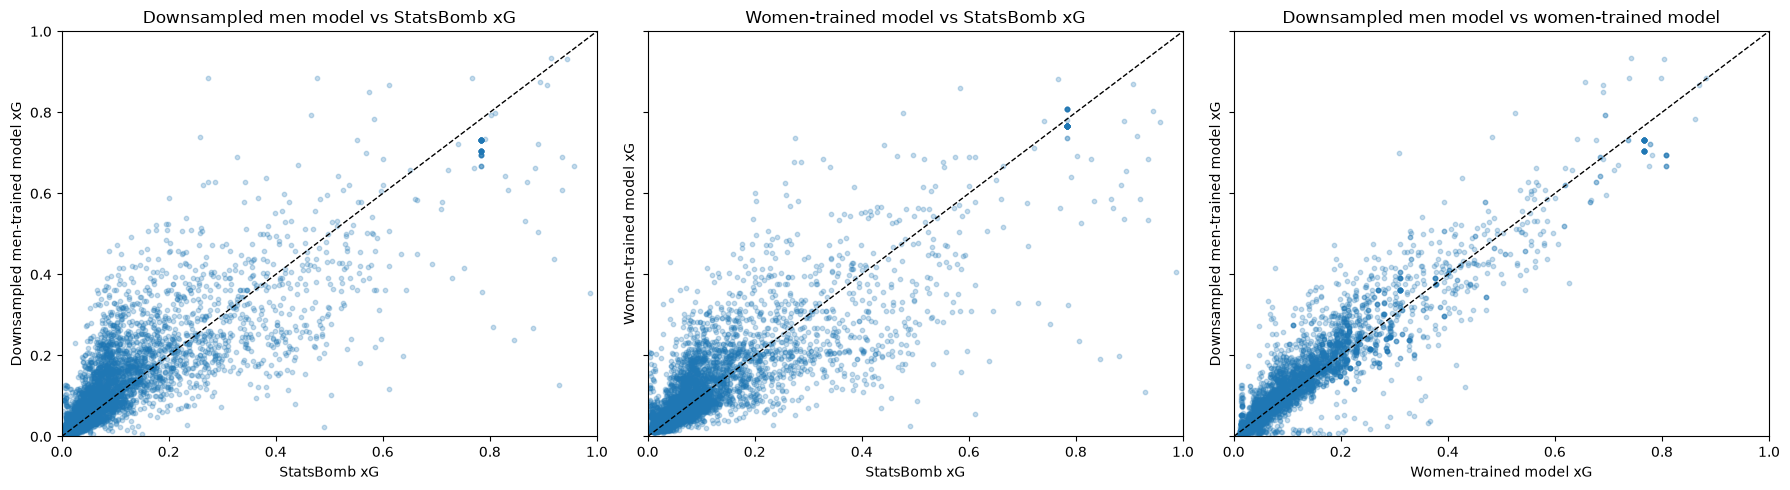

In [9]:
statsbomb_comparison_shots = xg_predictions.dropna(subset=["statsbomb_xg"]).copy()
if statsbomb_comparison_shots.empty:
    raise ValueError("No non-missing StatsBomb xG values found in the women test shots.")

prediction_columns = {
    "men_downsampled_trained_model": "men_downsampled_model_xg",
    "women_trained_model": "women_model_xg",
    "statsbomb_xg": "statsbomb_xg",
}

comparison_rows = []
for label, column in prediction_columns.items():
    prediction = statsbomb_comparison_shots[column]
    statsbomb_xg = statsbomb_comparison_shots["statsbomb_xg"]
    goals = statsbomb_comparison_shots["goal"]

    comparison_rows.append({
        "source": label,
        "shots": len(statsbomb_comparison_shots),
        "total_xg": prediction.sum(),
        "mean_xg": prediction.mean(),
        "mae_vs_statsbomb_xg": np.mean(np.abs(prediction - statsbomb_xg)),
        "rmse_vs_statsbomb_xg": np.sqrt(np.mean((prediction - statsbomb_xg) ** 2)),
        "pearson_vs_statsbomb_xg": prediction.corr(statsbomb_xg, method="pearson"),
        "spearman_vs_statsbomb_xg": prediction.corr(statsbomb_xg, method="spearman"),
        "brier_vs_goal": np.mean((prediction - goals) ** 2),
    })

print("指标说明：")
print("- source: 这一行对应的 xG 来源")
print("- shots: 参与比较的女足测试集射门数")
print("- total_xg: 这些射门的 xG 总和，用来看整体尺度/校准")
print("- mean_xg: 平均每脚射门的 xG")
print("- mae_vs_statsbomb_xg: 和 StatsBomb xG 的平均绝对差，越低越接近")
print("- rmse_vs_statsbomb_xg: 平方误差版本，更惩罚大的分歧")
print("- pearson_vs_statsbomb_xg: 和 StatsBomb xG 数值的线性相关")
print("- spearman_vs_statsbomb_xg: 和 StatsBomb xG 射门质量排序的相关")
print("- brier_vs_goal: 和实际进球结果 0/1 的均方误差，越低越好")
print()

model_vs_statsbomb_xg = pd.DataFrame(comparison_rows)
display(model_vs_statsbomb_xg.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
scatter_specs = [
    (
        "statsbomb_xg",
        "men_downsampled_model_xg",
        "StatsBomb xG",
        "Downsampled men-trained model xG",
        "Downsampled men model vs StatsBomb xG",
    ),
    (
        "statsbomb_xg",
        "women_model_xg",
        "StatsBomb xG",
        "Women-trained model xG",
        "Women-trained model vs StatsBomb xG",
    ),
    (
        "women_model_xg",
        "men_downsampled_model_xg",
        "Women-trained model xG",
        "Downsampled men-trained model xG",
        "Downsampled men model vs women-trained model",
    ),
]

max_xg = statsbomb_comparison_shots[
    ["statsbomb_xg", "men_downsampled_model_xg", "women_model_xg"]
].max().max()
axis_limit = min(1.0, max_xg * 1.05)

for axis, (x_column, y_column, x_label, y_label, title) in zip(axes, scatter_specs):
    axis.scatter(
        statsbomb_comparison_shots[x_column],
        statsbomb_comparison_shots[y_column],
        alpha=0.25,
        s=10,
    )
    axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_xlim(0, axis_limit)
    axis.set_ylim(0, axis_limit)

plt.tight_layout()
plt.show()

## 10. 补充诊断：男足 full set 和 downsized 的差异

这部分不是主比较，只是看男足训练数据更多带来的影响。如果 full men model 和 downsampled men model 的预测很接近，就说明训练数据量差异没有主导结果。

,comparison,left_column,right_column,mae_between_predictions,rmse_between_predictions,pearson_between_predictions,spearman_between_predictions
0,men_full_vs_men_downsampled,men_full_model_xg,men_downsampled_model_xg,0.0136,0.0222,0.9855,0.9812
1,men_full_vs_women,men_full_model_xg,women_model_xg,0.0231,0.0383,0.9579,0.9384
2,men_downsampled_vs_women,men_downsampled_model_xg,women_model_xg,0.0261,0.0445,0.9417,0.9277


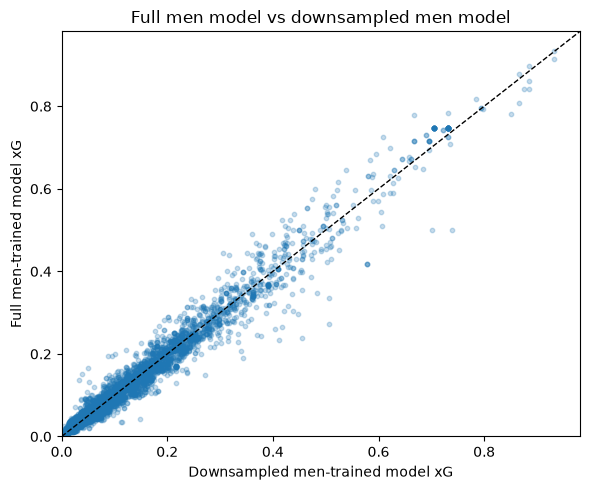

In [10]:
training_size_comparison_rows = []
comparison_pairs = [
    ("men_full_vs_men_downsampled", "men_full_model_xg", "men_downsampled_model_xg"),
    ("men_full_vs_women", "men_full_model_xg", "women_model_xg"),
    ("men_downsampled_vs_women", "men_downsampled_model_xg", "women_model_xg"),
]

for label, left_column, right_column in comparison_pairs:
    left = xg_predictions[left_column]
    right = xg_predictions[right_column]
    training_size_comparison_rows.append({
        "comparison": label,
        "left_column": left_column,
        "right_column": right_column,
        "mae_between_predictions": np.mean(np.abs(left - right)),
        "rmse_between_predictions": np.sqrt(np.mean((left - right) ** 2)),
        "pearson_between_predictions": left.corr(right, method="pearson"),
        "spearman_between_predictions": left.corr(right, method="spearman"),
    })

training_size_comparison = pd.DataFrame(training_size_comparison_rows)
display(training_size_comparison.round(4))

fig, axis = plt.subplots(figsize=(6, 5))
max_xg = xg_predictions[["men_full_model_xg", "men_downsampled_model_xg"]].max().max()
axis_limit = min(1.0, max_xg * 1.05)

axis.scatter(
    xg_predictions["men_downsampled_model_xg"],
    xg_predictions["men_full_model_xg"],
    alpha=0.25,
    s=10,
)
axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
axis.set_title("Full men model vs downsampled men model")
axis.set_xlabel("Downsampled men-trained model xG")
axis.set_ylabel("Full men-trained model xG")
axis.set_xlim(0, axis_limit)
axis.set_ylim(0, axis_limit)

plt.tight_layout()
plt.show()

## 11. 查看原始 `competition_events` 输出

这个可选诊断 cell 用来展示 `sb.matches(...)` 和 `sb.competition_events(...)`
在我们进行 xG 特征转换之前，原始返回的数据长什么样。

In [11]:
example_competition = WOMEN_COMPETITIONS[0]

example_matches = sb.matches(
    competition_id=example_competition["competition_id"],
    season_id=example_competition["season_id"],
)
print("sb.matches(...) shape:", example_matches.shape)
print("sb.matches(...) columns:")
print(example_matches.columns.tolist())

print("\nOne sb.matches(...) row:")
display(example_matches.head(1).T.rename(columns={example_matches.index[0]: "value"}))

example_competition_shots = sb.competition_events(
    country=example_competition["country"],
    division=example_competition["division"],
    season=example_competition["season"],
    gender=example_competition["gender"],
    filters={"type": "Shot"},
)
print("\nsb.competition_events(..., filters={'type': 'Shot'}) shape:", example_competition_shots.shape)
print("sb.competition_events(...) columns:")
print(example_competition_shots.columns.tolist())

shot_debug_columns = [
    "match_id",
    "minute",
    "second",
    "team",
    "player",
    "player_id",
    "position",
    "location",
    "play_pattern",
    "shot_type",
    "shot_body_part",
    "shot_technique",
    "shot_first_time",
    "under_pressure",
    "shot_outcome",
    "shot_statsbomb_xg",
]
shot_debug_columns = [column for column in shot_debug_columns if column in example_competition_shots.columns]

print("\nRaw shot rows from competition_events:")
display(example_competition_shots[shot_debug_columns].head(10))

print("\nRaw shot rows after event_to_xg_row(...):")
example_xg_rows = pd.DataFrame(
    [event_to_xg_row(shot_event, example_competition["league"]) for _, shot_event in example_competition_shots.head(10).iterrows()]
)
display(example_xg_rows)


sb.matches(...) shape: (132, 55)
sb.matches(...) columns:
['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'a

,value
match_id,3913082
match_date,2023-11-05
kick_off,18:45:00.000
home_score,2
away_score,2
match_status,available
match_status_360,unscheduled
last_updated,2026-04-11T13:03:17.779673
last_updated_360,None
match_week,5



sb.competition_events(..., filters={'type': 'Shot'}) shape: (3529, 39)
sb.competition_events(...) columns:
['duration', 'id', 'index', 'location', 'match_id', 'minute', 'off_camera', 'out', 'period', 'play_pattern', 'player', 'player_id', 'position', 'possession', 'possession_team', 'possession_team_id', 'related_events', 'second', 'shot_aerial_won', 'shot_body_part', 'shot_deflected', 'shot_end_location', 'shot_first_time', 'shot_freeze_frame', 'shot_key_pass_id', 'shot_one_on_one', 'shot_open_goal', 'shot_outcome', 'shot_redirect', 'shot_saved_off_target', 'shot_saved_to_post', 'shot_statsbomb_xg', 'shot_technique', 'shot_type', 'team', 'team_id', 'timestamp', 'type', 'under_pressure']

Raw shot rows from competition_events:


,match_id,minute,second,team,player,player_id,position,location,play_pattern,shot_type,shot_body_part,shot_technique,shot_first_time,under_pressure,shot_outcome,shot_statsbomb_xg
0,3913082,0,54,Manchester United W,Leah Galton,31539,Left Wing,"[112.1, 36.3]",From Kick Off,Open Play,Head,Normal,NaN,True,Blocked,0.080485
1,3913082,2,29,Manchester United W,Ella Toone,31534,Left Center Midfield,"[103.2, 34.0]",From Throw In,Open Play,Right Foot,Normal,NaN,NaN,Blocked,0.032564
2,3913082,2,32,Manchester United W,Hinata Miyazawa,401932,Right Center Midfield,"[97.4, 44.4]",From Throw In,Open Play,Right Foot,Normal,NaN,NaN,Blocked,0.039369
3,3913082,2,33,Manchester United W,Melvine Malard,31614,Right Wing,"[107.7, 38.8]",From Throw In,Open Play,Left Foot,Normal,True,True,Saved,0.269035
4,3913082,7,12,Manchester United W,Geyse da Silva Ferreira,25543,Center Forward,"[115.5, 53.9]",Regular Play,Open Play,Right Foot,Normal,NaN,NaN,Off T,0.015162
5,3913082,18,1,Brighton & Hove Albion WFC,Madison Haley,405188,Right Wing,"[114.9, 42.6]",From Corner,Open Play,Head,Normal,NaN,True,Blocked,0.124237
6,3913082,18,15,Brighton & Hove Albion WFC,Elisabeth Terland,276301,Center Forward,"[105.7, 42.2]",From Corner,Open Play,Right Foot,Normal,True,NaN,Saved,0.108810
7,3913082,20,18,Brighton & Hove Albion WFC,Jorelyn Andrea Daniela Carabalí Martínez,388473,Left Center Back,"[111.5, 37.3]",From Corner,Open Play,Head,Normal,NaN,True,Saved,0.065711
8,3913082,27,48,Brighton & Hove Albion WFC,Elisabeth Terland,276301,Center Forward,"[102.8, 31.3]",From Free Kick,Open Play,Right Foot,Half Volley,True,NaN,Off T,0.086174
9,3913082,29,25,Brighton & Hove Albion WFC,Maisie Symonds,85004,Left Defensive Midfield,"[101.5, 52.6]",From Counter,Open Play,Right Foot,Normal,NaN,NaN,Wayward,0.042489



Raw shot rows after event_to_xg_row(...):


,game_id,player_id,league,shot_x,shot_y,distance,angle,body_part,shot_technique,shot_type,play_pattern,shot_context,under_pressure,first_time,statsbomb_xg,goal
0,3913082,31539,WSL,112.1,36.3,7.594319,0.851927,Head,Normal,Open Play,From Kick Off,Set Piece,True,False,0.080485,0
1,3913082,31534,WSL,103.2,34.0,15.559563,0.439765,Right Foot,Normal,Open Play,From Throw In,Set Piece,False,False,0.032564,0
2,3913082,401932,WSL,97.4,44.4,20.125561,0.354032,Right Foot,Normal,Open Play,From Throw In,Set Piece,False,False,0.039369,0
3,3913082,31614,WSL,107.7,38.8,10.810726,0.650725,Left Foot,Normal,Open Play,From Throw In,Set Piece,True,True,0.269035,0
4,3913082,25543,WSL,115.5,53.9,12.453840,0.200664,Right Foot,Normal,Open Play,Regular Play,Open Play,False,False,0.015162,0
5,3913082,405188,WSL,114.9,42.6,4.979760,1.234954,Head,Normal,Open Play,From Corner,Set Piece,True,False,0.124237,0
6,3913082,276301,WSL,105.7,42.2,12.651465,0.558239,Right Foot,Normal,Open Play,From Corner,Set Piece,False,True,0.108810,0
7,3913082,388473,WSL,111.5,37.3,7.783536,0.856660,Head,Normal,Open Play,From Corner,Set Piece,True,False,0.065711,0
8,3913082,276301,WSL,102.8,31.3,16.768677,0.390282,Right Foot,Half Volley,Open Play,From Free Kick,Free Kick,False,True,0.086174,0
9,3913082,85004,WSL,101.5,52.6,19.409772,0.315242,Right Foot,Normal,Open Play,From Counter,Open Play,False,False,0.042489,0


## 12. 按射门位置 grid 比较男足 xG 和女足 xG 的打分差异

这一节只看 held-out women test set 里的射门，也就是 xg_predictions。

我们把球场按 StatsBomb 坐标切成 grid，然后在每个 grid 里比较两种模型给同一批测试射门的 xG：

- men_downsampled_model_xg：用男足下采样训练集训练出的 xG 模型。
- women_model_xg：用女足训练集训练出的 xG 模型。
- delta = men_downsampled_model_xg - women_model_xg。

每个 grid 会统计：

- shot_count：女足 test set 在这个 grid 内有多少脚射门。
- aggregate_delta：这个 grid 内所有射门的 delta 总和。
- mean_delta：这个 grid 内平均每脚射门的 delta。
- delta_std：这个 grid 内 delta 的标准差。
- min_grid_shots：默认只展示/可视化至少 10 脚射门的 grid，避免少量样本带来的噪音。

注意：这个分析不是纯粹只比较坐标本身。xG 模型输入还包括 body part、technique、shot type、play pattern、pressure 等特征。所以这里的含义是：在同一个射门位置 grid 内，男足模型和女足模型对该 grid 中实际出现的女足测试射门给分有什么差异。


In [12]:
XG_GRID_ROWS = 12
XG_GRID_COLS = 16
MIN_GRID_SHOTS = 10
STATSBOMB_PITCH_LENGTH = 120.0
STATSBOMB_PITCH_WIDTH = 80.0


def add_xg_grid_columns(shots, rows=XG_GRID_ROWS, cols=XG_GRID_COLS):
    """Assign each shot to a StatsBomb-coordinate pitch grid cell."""
    shots = shots.copy()
    shot_x = pd.to_numeric(shots["shot_x"], errors="coerce")
    shot_y = pd.to_numeric(shots["shot_y"], errors="coerce")

    clipped_x = np.clip(shot_x, 0, np.nextafter(STATSBOMB_PITCH_LENGTH, 0))
    clipped_y = np.clip(shot_y, 0, np.nextafter(STATSBOMB_PITCH_WIDTH, 0))

    shots["grid_col"] = np.floor(clipped_x / STATSBOMB_PITCH_LENGTH * cols).astype("Int64")
    shots["grid_row"] = np.floor(clipped_y / STATSBOMB_PITCH_WIDTH * rows).astype("Int64")

    cell_width = STATSBOMB_PITCH_LENGTH / cols
    cell_height = STATSBOMB_PITCH_WIDTH / rows
    shots["grid_x_min"] = shots["grid_col"].astype(float) * cell_width
    shots["grid_x_max"] = shots["grid_x_min"] + cell_width
    shots["grid_y_min"] = shots["grid_row"].astype(float) * cell_height
    shots["grid_y_max"] = shots["grid_y_min"] + cell_height
    return shots


def summarize_xg_delta_by_grid(
    predictions,
    men_column="men_downsampled_model_xg",
    women_column="women_model_xg",
    rows=XG_GRID_ROWS,
    cols=XG_GRID_COLS,
):
    """Summarize men-vs-women xG prediction deltas inside each shot-location grid."""
    grid_predictions = add_xg_grid_columns(predictions, rows=rows, cols=cols)
    grid_predictions = grid_predictions.dropna(subset=["grid_row", "grid_col", men_column, women_column]).copy()
    grid_predictions["xg_delta"] = grid_predictions[men_column] - grid_predictions[women_column]

    grid_summary = (
        grid_predictions.groupby(["grid_row", "grid_col"], observed=True)
        .agg(
            shot_count=("xg_delta", "size"),
            aggregate_delta=("xg_delta", "sum"),
            mean_delta=("xg_delta", "mean"),
            delta_std=("xg_delta", "std"),
            mean_men_xg=(men_column, "mean"),
            mean_women_xg=(women_column, "mean"),
        )
        .reset_index()
    )

    all_cells = pd.MultiIndex.from_product(
        [range(rows), range(cols)],
        names=["grid_row", "grid_col"],
    ).to_frame(index=False)
    grid_summary = all_cells.merge(grid_summary, on=["grid_row", "grid_col"], how="left")
    grid_summary["shot_count"] = grid_summary["shot_count"].fillna(0).astype(int)
    grid_summary["aggregate_delta"] = grid_summary["aggregate_delta"].fillna(0)
    grid_summary["delta_std"] = grid_summary["delta_std"].fillna(0)

    cell_width = STATSBOMB_PITCH_LENGTH / cols
    cell_height = STATSBOMB_PITCH_WIDTH / rows
    grid_summary["grid_x_min"] = grid_summary["grid_col"] * cell_width
    grid_summary["grid_x_max"] = grid_summary["grid_x_min"] + cell_width
    grid_summary["grid_y_min"] = grid_summary["grid_row"] * cell_height
    grid_summary["grid_y_max"] = grid_summary["grid_y_min"] + cell_height
    grid_summary["grid_label"] = (
        "r" + grid_summary["grid_row"].astype(str)
        + "_c" + grid_summary["grid_col"].astype(str)
    )
    return grid_predictions, grid_summary


xg_grid_predictions, xg_grid_delta_summary = summarize_xg_delta_by_grid(xg_predictions)

print("Grid delta definition: men_downsampled_model_xg - women_model_xg")
print(f"women test shots assigned to grid: {len(xg_grid_predictions):,} of {len(xg_predictions):,}")
valid_grid_mask = xg_grid_delta_summary["shot_count"] >= MIN_GRID_SHOTS
valid_xg_grid_delta_summary = xg_grid_delta_summary[valid_grid_mask].copy()

print(f"non-empty grid cells: {(xg_grid_delta_summary.shot_count > 0).sum()} of {len(xg_grid_delta_summary)}")
print(f"grid cells with at least {MIN_GRID_SHOTS} shots: {valid_grid_mask.sum()} of {len(xg_grid_delta_summary)}")

print("\nMost common shot grids in women test set:")
display(
    valid_xg_grid_delta_summary
    .sort_values("shot_count", ascending=False)
    .head(15)
    .round(4)
)

print("\nLargest absolute aggregate deltas by grid:")
display(
    valid_xg_grid_delta_summary
    .assign(abs_aggregate_delta=lambda frame: frame["aggregate_delta"].abs())
    .sort_values("abs_aggregate_delta", ascending=False)
    .head(15)
    .round(4)
)


Grid delta definition: men_downsampled_model_xg - women_model_xg
women test shots assigned to grid: 5,965 of 5,965
non-empty grid cells: 73 of 192
grid cells with at least 10 shots: 40 of 192

Most common shot grids in women test set:


,grid_row,grid_col,shot_count,aggregate_delta,mean_delta,delta_std,mean_men_xg,mean_women_xg,grid_x_min,grid_x_max,grid_y_min,grid_y_max,grid_label
110,6,14,599,10.5164,0.0176,0.0517,0.2174,0.1998,105.0,112.5,40.0000,46.6667,r6_c14
94,5,14,502,9.9913,0.0199,0.0460,0.1644,0.1445,105.0,112.5,33.3333,40.0000,r5_c14
95,5,15,370,5.8771,0.0159,0.0780,0.2909,0.2750,112.5,120.0,33.3333,40.0000,r5_c15
78,4,14,344,5.9347,0.0173,0.0427,0.1335,0.1163,105.0,112.5,26.6667,33.3333,r4_c14
111,6,15,339,4.6159,0.0136,0.0780,0.3045,0.2909,112.5,120.0,40.0000,46.6667,r6_c15
109,6,13,326,2.7552,0.0085,0.0397,0.0960,0.0876,97.5,105.0,40.0000,46.6667,r6_c13
126,7,14,324,7.0869,0.0219,0.0311,0.1404,0.1185,105.0,112.5,46.6667,53.3333,r7_c14
77,4,13,277,1.3553,0.0049,0.0287,0.0631,0.0582,97.5,105.0,26.6667,33.3333,r4_c13
93,5,13,273,2.8948,0.0106,0.0359,0.0975,0.0869,97.5,105.0,33.3333,40.0000,r5_c13
125,7,13,265,1.7957,0.0068,0.0258,0.0645,0.0577,97.5,105.0,46.6667,53.3333,r7_c13



Largest absolute aggregate deltas by grid:


,grid_row,grid_col,shot_count,aggregate_delta,mean_delta,delta_std,mean_men_xg,mean_women_xg,grid_x_min,grid_x_max,grid_y_min,grid_y_max,grid_label,abs_aggregate_delta
110,6,14,599,10.5164,0.0176,0.0517,0.2174,0.1998,105.0,112.5,40.0000,46.6667,r6_c14,10.5164
94,5,14,502,9.9913,0.0199,0.0460,0.1644,0.1445,105.0,112.5,33.3333,40.0000,r5_c14,9.9913
126,7,14,324,7.0869,0.0219,0.0311,0.1404,0.1185,105.0,112.5,46.6667,53.3333,r7_c14,7.0869
78,4,14,344,5.9347,0.0173,0.0427,0.1335,0.1163,105.0,112.5,26.6667,33.3333,r4_c14,5.9347
95,5,15,370,5.8771,0.0159,0.0780,0.2909,0.2750,112.5,120.0,33.3333,40.0000,r5_c15,5.8771
111,6,15,339,4.6159,0.0136,0.0780,0.3045,0.2909,112.5,120.0,40.0000,46.6667,r6_c15,4.6159
127,7,15,159,3.0336,0.0191,0.0310,0.1148,0.0957,112.5,120.0,46.6667,53.3333,r7_c15,3.0336
93,5,13,273,2.8948,0.0106,0.0359,0.0975,0.0869,97.5,105.0,33.3333,40.0000,r5_c13,2.8948
109,6,13,326,2.7552,0.0085,0.0397,0.0960,0.0876,97.5,105.0,40.0000,46.6667,r6_c13,2.7552
79,4,15,157,2.6648,0.0170,0.0380,0.1204,0.1034,112.5,120.0,26.6667,33.3333,r4_c15,2.6648


## 12.1 2D pitch visualization

下面四张图都只基于女足 test set 射门，并且默认只显示 `shot_count >= MIN_GRID_SHOTS` 的 grid：

- shot_count 看满足阈值后的样本分布，避免过度解读少量射门的 grid。
- aggregate_delta 看某个区域对总体差异贡献多大。
- mean_delta 看该区域平均每脚射门男足模型比女足模型给得更高还是更低。
- delta_std 看该区域内部不同射门之间的差异是否稳定。

红/蓝差值图里，正值表示男足模型给的 xG 更高，负值表示女足模型给的 xG 更高。


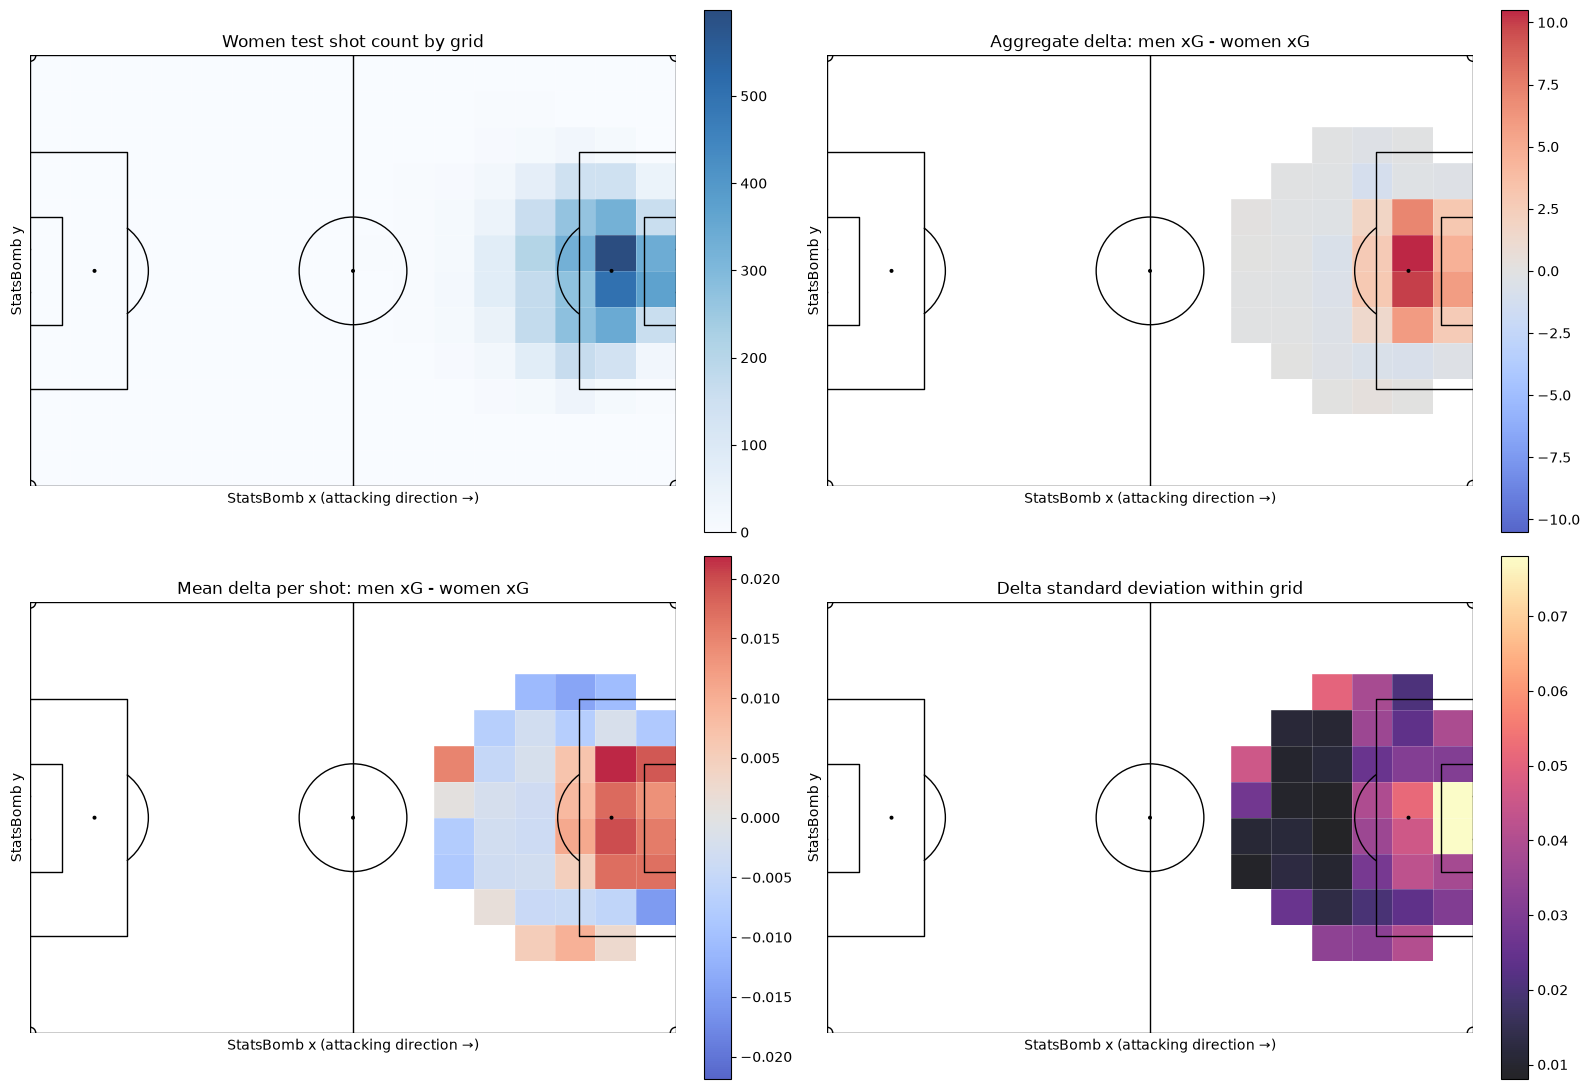

In [13]:
def grid_metric_matrix(grid_summary, metric, rows=XG_GRID_ROWS, cols=XG_GRID_COLS):
    """Convert a grid summary column into a rows x cols matrix for imshow."""
    matrix = np.full((rows, cols), np.nan)
    for row in grid_summary.itertuples(index=False):
        value = getattr(row, metric)
        matrix[int(row.grid_row), int(row.grid_col)] = value
    return matrix


def mask_low_sample_grids(grid_summary, min_shots=MIN_GRID_SHOTS):
    """Return a copy where metric columns are hidden for low-sample grid cells."""
    grid_summary = grid_summary.copy()
    low_sample_mask = grid_summary["shot_count"] < min_shots
    metric_columns = ["aggregate_delta", "mean_delta", "delta_std", "mean_men_xg", "mean_women_xg"]
    grid_summary.loc[low_sample_mask, metric_columns] = np.nan
    return grid_summary


def plot_xg_grid_heatmap(axis, grid_summary, metric, title, cmap="viridis", center_zero=False):
    """Plot one grid metric over a StatsBomb pitch."""
    matrix = grid_metric_matrix(grid_summary, metric)
    matrix = np.ma.masked_invalid(matrix)

    vmin = vmax = None
    if center_zero:
        max_abs_value = np.nanmax(np.abs(matrix.filled(np.nan)))
        if np.isfinite(max_abs_value) and max_abs_value > 0:
            vmin = -max_abs_value
            vmax = max_abs_value

    colormap = plt.get_cmap(cmap).copy()
    colormap.set_bad(color="white", alpha=0.0)

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="white",
        line_color="black",
        linewidth=1.0,
        line_zorder=3,
        goal_type="box",
        corner_arcs=True,
    )
    pitch.draw(ax=axis)

    image = axis.imshow(
        matrix,
        origin="lower",
        extent=[0, STATSBOMB_PITCH_LENGTH, 0, STATSBOMB_PITCH_WIDTH],
        aspect="equal",
        cmap=colormap,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
        alpha=0.86,
        zorder=1,
    )

    for x_value in np.linspace(0, STATSBOMB_PITCH_LENGTH, XG_GRID_COLS + 1):
        axis.plot([x_value, x_value], [0, STATSBOMB_PITCH_WIDTH], color="white", alpha=0.35, linewidth=0.4, zorder=2)
    for y_value in np.linspace(0, STATSBOMB_PITCH_WIDTH, XG_GRID_ROWS + 1):
        axis.plot([0, STATSBOMB_PITCH_LENGTH], [y_value, y_value], color="white", alpha=0.35, linewidth=0.4, zorder=2)

    axis.set_title(title)
    axis.set_xlabel("StatsBomb x (attacking direction →)")
    axis.set_ylabel("StatsBomb y")
    axis.set_xlim(0, STATSBOMB_PITCH_LENGTH)
    axis.set_ylim(0, STATSBOMB_PITCH_WIDTH)
    axis.set_aspect("equal", adjustable="box")
    plt.colorbar(image, ax=axis, fraction=0.046, pad=0.04)


plot_grid_summary = mask_low_sample_grids(xg_grid_delta_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

plot_xg_grid_heatmap(
    axes[0, 0],
    plot_grid_summary,
    "shot_count",
    "Women test shot count by grid",
    cmap="Blues",
)
plot_xg_grid_heatmap(
    axes[0, 1],
    plot_grid_summary,
    "aggregate_delta",
    "Aggregate delta: men xG - women xG",
    cmap="coolwarm",
    center_zero=True,
)
plot_xg_grid_heatmap(
    axes[1, 0],
    plot_grid_summary,
    "mean_delta",
    "Mean delta per shot: men xG - women xG",
    cmap="coolwarm",
    center_zero=True,
)
plot_xg_grid_heatmap(
    axes[1, 1],
    plot_grid_summary,
    "delta_std",
    "Delta standard deviation within grid",
    cmap="magma",
)

plt.tight_layout()
plt.show()


## 13. 按球员主要位置 bucket 比较男足 xG 和女足 xG 的排名影响

前面的 player-level xG 比较是把所有满足最小射门数的女足 test-set 球员放在一起，直接比较男足 xG 模型和女足 xG 模型给出的球员总 xG 与排名。

这一节把同一批 test-set 球员按主要场上位置分到 position bucket 中，然后在每个 bucket 内分别看：

- 男足模型 xG 总和 vs 女足模型 xG 总和的 Spearman 排名相关。
- 男足模型相对女足模型的 xG 总分差异。
- 男足模型是否会在该位置 bucket 内把某些球员排得更高或更低。

这里的主要位置来自女足 competition-events position cache。也就是说，我们先估计每个 test-set player 最常出现的位置，再把细位置合并成更粗的 bucket。


In [14]:
POSITION_CACHE_CANDIDATES = [
    CACHE_DIR / "women_positions_competition_events_method.pkl",
    CACHE_DIR / "women_positions_statsbombpy_remote.pkl",
]

MIN_PLAYERS_FOR_BUCKET_SPEARMAN = 2


def load_women_position_rows():
    """Load cached women player-position observations."""
    for position_cache in POSITION_CACHE_CANDIDATES:
        if position_cache.exists():
            print(f"[cache] women positions: {position_cache}")
            positions = pd.read_pickle(position_cache).copy()
            break
    else:
        raise FileNotFoundError(
            "No women position cache found. Run the position-loading notebook/cell first, "
            "or create vaep_data/women_positions_competition_events_method.pkl."
        )

    required_columns = {"player_id", "position_name"}
    missing_columns = required_columns.difference(positions.columns)
    if missing_columns:
        raise ValueError(f"Position cache missing columns: {sorted(missing_columns)}")

    positions = positions[list(required_columns)].dropna().copy()
    positions["player_id_key"] = pd.to_numeric(positions["player_id"], errors="coerce").astype("Int64")
    positions["position_name"] = positions["position_name"].astype(str)
    positions = positions.dropna(subset=["player_id_key", "position_name"])
    return positions


def build_primary_position_table(position_rows):
    """Choose the most frequent observed position for each player."""
    position_counts = (
        position_rows.groupby(["player_id_key", "position_name"])
        .size()
        .reset_index(name="position_observations")
        .sort_values(["player_id_key", "position_observations", "position_name"], ascending=[True, False, True])
    )

    primary_positions = (
        position_counts.groupby("player_id_key", as_index=False)
        .first()
        .rename(columns={"position_name": "primary_position"})
    )
    return primary_positions


def bucket_position(position_name):
    """Map granular StatsBomb positions to broad tactical buckets."""
    position_name = str(position_name)

    if "Goalkeeper" in position_name:
        return "Goalkeeper"
    if "Center Back" in position_name:
        return "Center Back"
    if "Wing Back" in position_name or position_name in {"Left Back", "Right Back"}:
        return "Fullback / Wing Back"
    if "Defensive Midfield" in position_name:
        return "Defensive Midfield"
    if "Center Midfield" in position_name:
        return "Central Midfield"
    if "Attacking Midfield" in position_name:
        return "Attacking Midfield"
    if position_name in {"Left Midfield", "Right Midfield", "Left Wing", "Right Wing"}:
        return "Wide Midfielder / Winger"
    if "Center Forward" in position_name or position_name == "Striker":
        return "Forward"
    return "Other / Unknown"


def spearman_if_available(left, right, min_players=MIN_PLAYERS_FOR_BUCKET_SPEARMAN):
    """Return Spearman correlation when there are enough non-constant players."""
    if len(left) < min_players:
        return np.nan
    if left.nunique(dropna=True) < 2 or right.nunique(dropna=True) < 2:
        return np.nan
    return stats.spearmanr(left, right)[0]


women_position_rows = load_women_position_rows()
primary_positions = build_primary_position_table(women_position_rows)
primary_positions["position_bucket"] = primary_positions["primary_position"].map(bucket_position)

player_xg_by_position = player_xg_comparison.copy()
player_xg_by_position["player_id_key"] = pd.to_numeric(
    player_xg_by_position["player_id"],
    errors="coerce",
).astype("Int64")

player_xg_by_position = player_xg_by_position.merge(
    primary_positions,
    on="player_id_key",
    how="left",
)
player_xg_by_position["primary_position"] = player_xg_by_position["primary_position"].fillna("Unknown")
player_xg_by_position["position_bucket"] = player_xg_by_position["position_bucket"].fillna("Other / Unknown")
player_xg_by_position["xg_delta"] = (
    player_xg_by_position["men_downsampled_xg"] - player_xg_by_position["women_xg"]
)
player_xg_by_position["abs_xg_delta"] = player_xg_by_position["xg_delta"].abs()

player_xg_by_position["bucket_men_rank"] = player_xg_by_position.groupby("position_bucket")[
    "men_downsampled_xg"
].rank(ascending=False, method="min")
player_xg_by_position["bucket_women_rank"] = player_xg_by_position.groupby("position_bucket")[
    "women_xg"
].rank(ascending=False, method="min")
player_xg_by_position["bucket_rank_delta"] = (
    player_xg_by_position["bucket_men_rank"] - player_xg_by_position["bucket_women_rank"]
)
player_xg_by_position["abs_bucket_rank_delta"] = player_xg_by_position["bucket_rank_delta"].abs()

bucket_summary_rows = []
for position_bucket, bucket_players in player_xg_by_position.groupby("position_bucket"):
    bucket_summary_rows.append(
        {
            "position_bucket": position_bucket,
            "players": len(bucket_players),
            "shots": int(bucket_players["shot_count"].sum()),
            "spearman_men_vs_women_xg": spearman_if_available(
                bucket_players["men_downsampled_xg"],
                bucket_players["women_xg"],
            ),
            "aggregate_xg_delta": bucket_players["xg_delta"].sum(),
            "mean_xg_delta": bucket_players["xg_delta"].mean(),
            "median_xg_delta": bucket_players["xg_delta"].median(),
            "mean_abs_xg_delta": bucket_players["abs_xg_delta"].mean(),
            "mean_bucket_rank_delta": bucket_players["bucket_rank_delta"].mean(),
            "median_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].median(),
            "max_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].max(),
        }
    )

position_bucket_xg_summary = (
    pd.DataFrame(bucket_summary_rows)
    .sort_values(["players", "shots"], ascending=False)
    .reset_index(drop=True)
)

print("Position-bucket summary for women test-set players with at least", MIN_SHOTS_PER_PLAYER, "shots:")
display(position_bucket_xg_summary.round(4))

print("\nPlayers with largest within-bucket rank changes:")
display(
    player_xg_by_position.sort_values("abs_bucket_rank_delta", ascending=False)[
        [
            "player_id",
            "primary_position",
            "position_bucket",
            "shot_count",
            "men_downsampled_xg",
            "women_xg",
            "xg_delta",
            "bucket_men_rank",
            "bucket_women_rank",
            "bucket_rank_delta",
        ]
    ]
    .head(25)
    .round(4)
)


[cache] women positions: vaep_data\women_positions_competition_events_method.pkl
Position-bucket summary for women test-set players with at least 10 shots:


,position_bucket,players,shots,spearman_men_vs_women_xg,aggregate_xg_delta,mean_xg_delta,median_xg_delta,mean_abs_xg_delta,mean_bucket_rank_delta,median_abs_bucket_rank_delta,max_abs_bucket_rank_delta
0,Forward,70,1137,0.9589,11.5187,0.1646,0.1544,0.2127,0.0,2.5,22.0
1,Wide Midfielder / Winger,63,987,0.9704,7.6198,0.1209,0.1107,0.1726,0.0,2.0,14.0
2,Defensive Midfield,24,329,0.9130,0.6471,0.0270,0.0218,0.1130,0.0,1.0,10.0
3,Attacking Midfield,19,271,0.9825,2.0753,0.1092,0.0621,0.1471,0.0,0.0,3.0
4,Central Midfield,16,210,0.9529,1.2389,0.0774,0.0477,0.1263,0.0,1.0,4.0
5,Fullback / Wing Back,7,83,0.8571,-0.1403,-0.0200,-0.0218,0.0733,0.0,0.0,2.0



Players with largest within-bucket rank changes:


,player_id,primary_position,position_bucket,shot_count,men_downsampled_xg,women_xg,xg_delta,bucket_men_rank,bucket_women_rank,bucket_rank_delta
171,321541,Center Forward,Forward,16,2.7314,1.8309,0.9005,14.0,36.0,-22.0
194,409156,Right Center Forward,Forward,22,1.5837,1.8233,-0.2396,54.0,37.0,17.0
11,10143,Center Forward,Forward,12,1.9021,2.2933,-0.3912,38.0,23.0,15.0
144,106836,Right Wing,Wide Midfielder / Winger,13,1.1462,1.4294,-0.2832,48.0,34.0,14.0
97,46878,Left Wing,Wide Midfielder / Winger,15,1.4380,1.6163,-0.1782,37.0,24.0,13.0
5,5055,Center Forward,Forward,25,2.6784,2.1156,0.5628,16.0,28.0,-12.0
104,46991,Right Center Forward,Forward,16,1.6243,1.7273,-0.1030,51.0,40.0,11.0
191,408715,Left Defensive Midfield,Defensive Midfield,10,1.3893,0.8973,0.4920,6.0,16.0,-10.0
185,389495,Left Wing,Wide Midfielder / Winger,10,1.3527,1.0454,0.3073,40.0,50.0,-10.0
157,136545,Center Forward,Forward,16,2.2688,2.3299,-0.0610,31.0,21.0,10.0


## 13.1 按场上位置分类的visualization

下面几张图从位置维度解释男足 xG 和女足 xG 对球员排名的影响：

- Spearman 越接近 1，说明该位置 bucket 内男足模型和女足模型给出的球员排序越接近。
- xG delta 为正，表示男足模型给该球员/位置的总 xG 更高；为负则表示女足模型更高。
- bucket rank delta = 男足模型 bucket 内排名 - 女足模型 bucket 内排名。因为 rank 1 最好，所以负值表示男足模型把该球员排得更高。


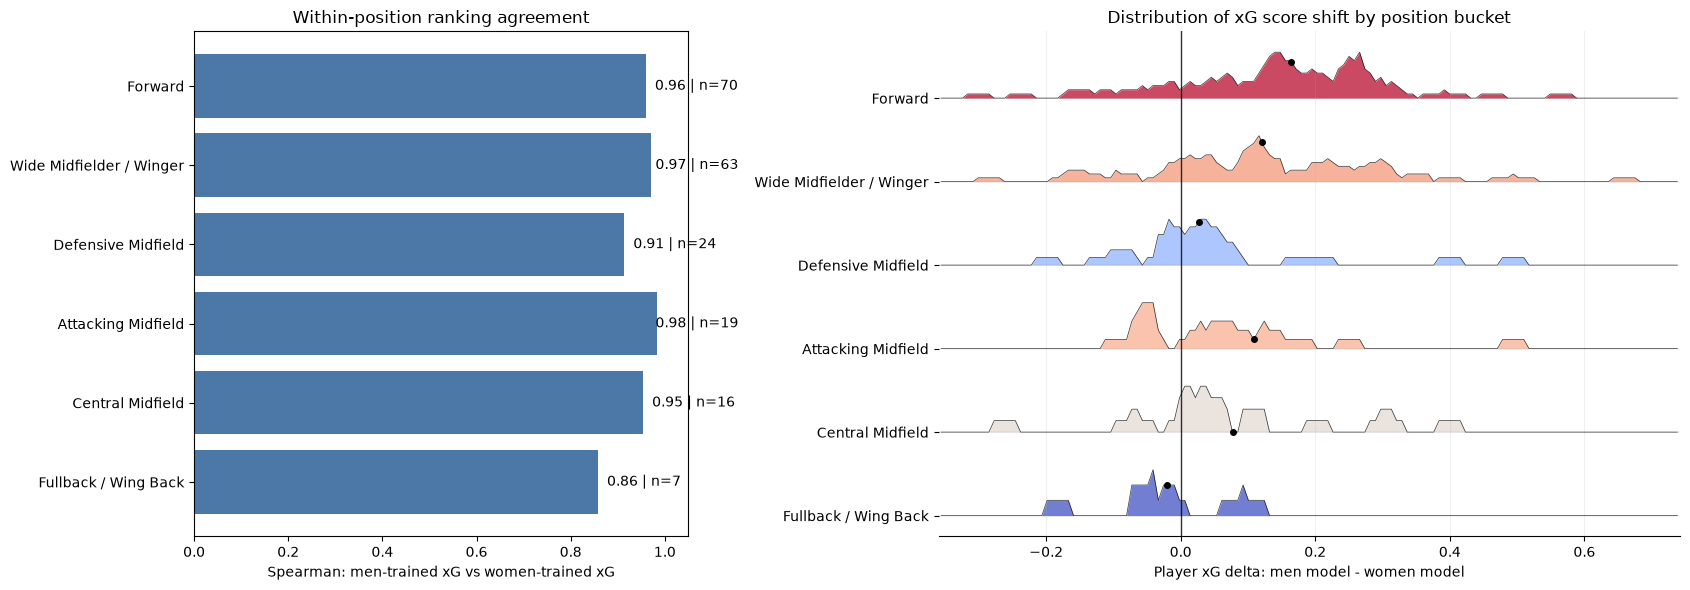

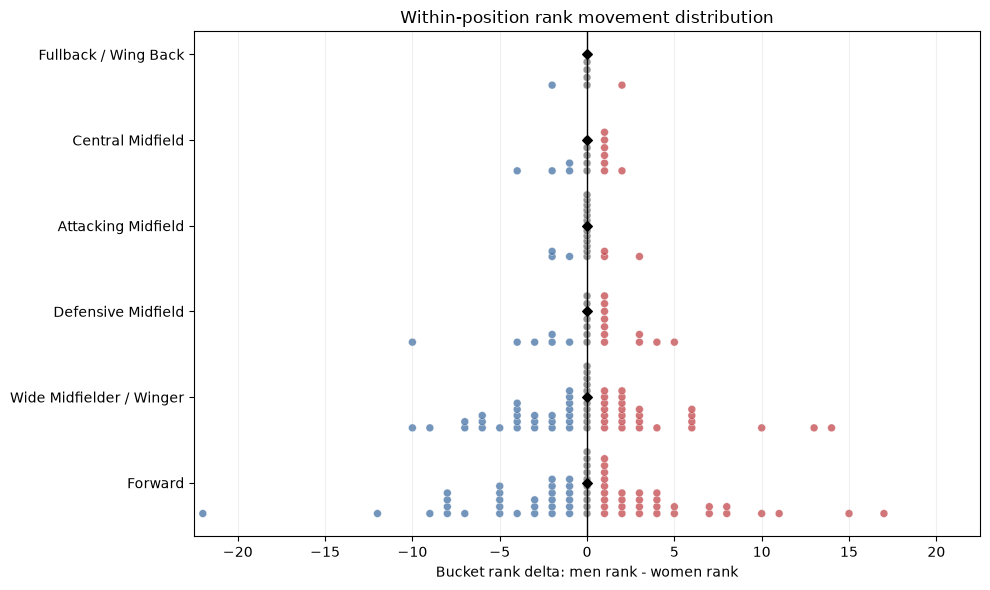

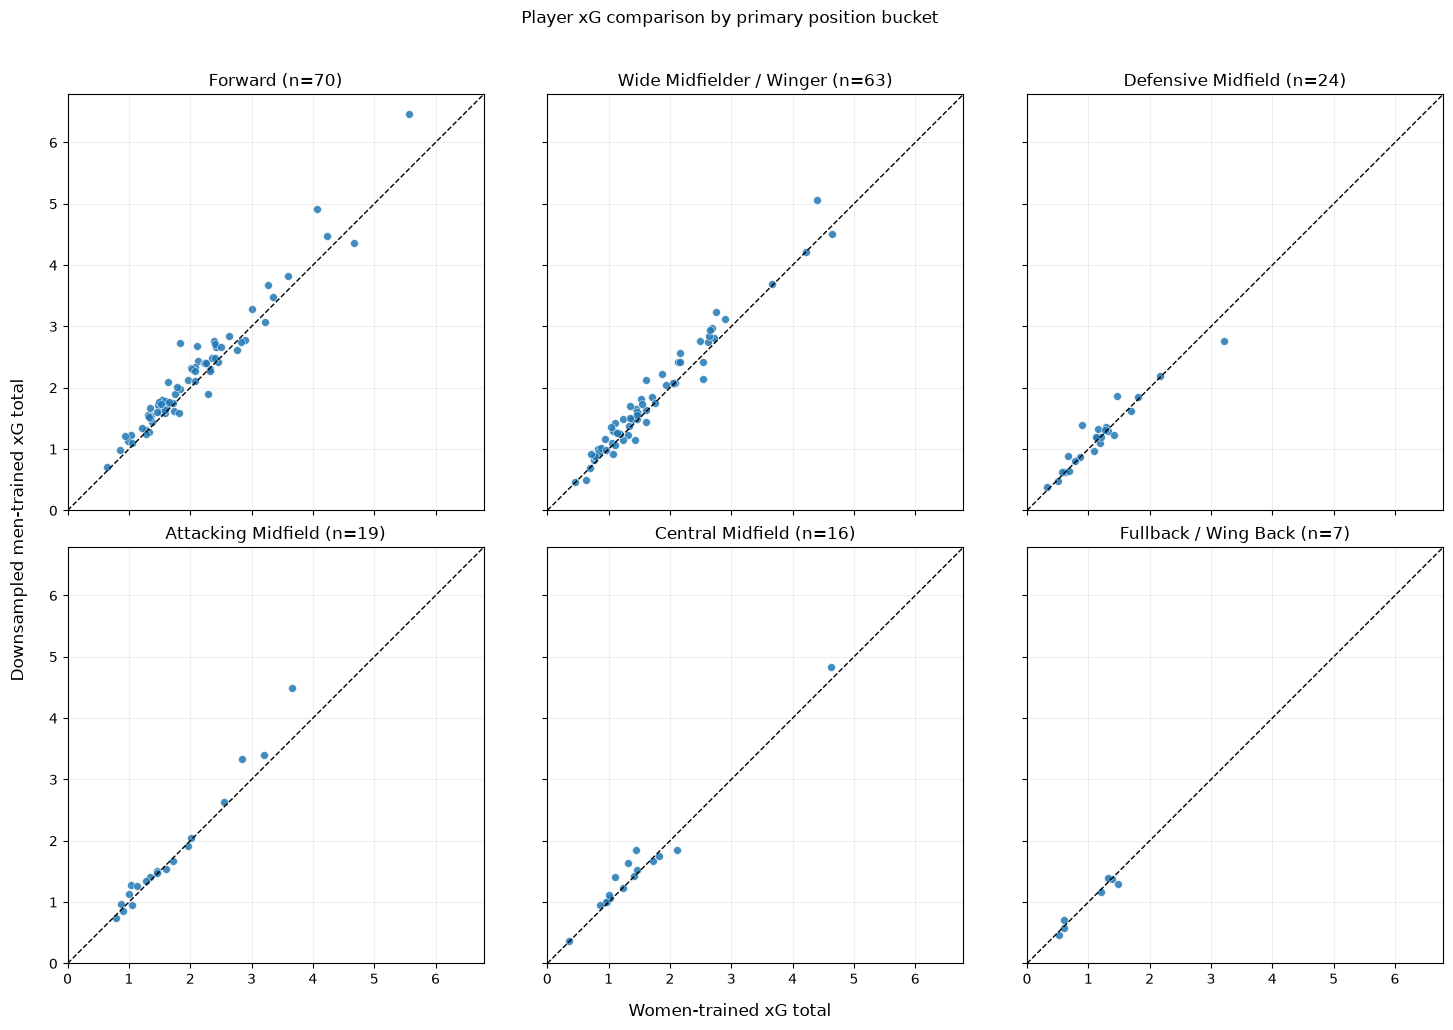

In [21]:
plot_bucket_summary = position_bucket_xg_summary.copy()
plot_bucket_summary = plot_bucket_summary.sort_values("players", ascending=True)
position_bucket_order = plot_bucket_summary["position_bucket"].tolist()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, max(6, 0.45 * len(position_bucket_order) + 2)),
    gridspec_kw={"width_ratios": [0.9, 1.35]},
)

axes[0].barh(
    plot_bucket_summary["position_bucket"],
    plot_bucket_summary["spearman_men_vs_women_xg"],
    color="#4C78A8",
)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("Spearman: men-trained xG vs women-trained xG")
axes[0].set_title("Within-position ranking agreement")
for y_index, row in enumerate(plot_bucket_summary.itertuples(index=False)):
    label = "n=" + str(row.players)
    if pd.notna(row.spearman_men_vs_women_xg):
        label = f"{row.spearman_men_vs_women_xg:.2f} | " + label
    axes[0].text(
        0.02 if pd.isna(row.spearman_men_vs_women_xg) else min(row.spearman_men_vs_women_xg + 0.02, 0.98),
        y_index,
        label,
        va="center",
    )

POSITION_DISTRIBUTION_BINS = 140
POSITION_DISTRIBUTION_QUANTILES = (0.02, 0.98)
POSITION_SMOOTHING_WINDOW = 5
POSITION_RIDGE_HEIGHT = 0.55
POSITION_ROW_SPACING = 1.0

position_distribution_rows = player_xg_by_position[
    player_xg_by_position["position_bucket"].isin(position_bucket_order)
].copy()

x_min, x_max = position_distribution_rows["xg_delta"].quantile(POSITION_DISTRIBUTION_QUANTILES)
if np.isclose(x_min, x_max):
    x_min -= 0.001
    x_max += 0.001

x_padding = 0.08 * (x_max - x_min)
x_min -= x_padding
x_max += x_padding

bin_edges = np.linspace(x_min, x_max, POSITION_DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(POSITION_SMOOTHING_WINDOW) / POSITION_SMOOTHING_WINDOW

cmap = plt.colormaps["coolwarm"]
color_min = plot_bucket_summary["mean_xg_delta"].min()
color_max = plot_bucket_summary["mean_xg_delta"].max()
if np.isclose(color_min, color_max):
    color_min -= 0.001
    color_max += 0.001
color_norm = plt.Normalize(color_min, color_max)
y_positions = np.arange(len(position_bucket_order)) * POSITION_ROW_SPACING

for y_position, position_bucket in zip(y_positions, position_bucket_order):
    values = position_distribution_rows.loc[
        position_distribution_rows["position_bucket"] == position_bucket,
        "xg_delta",
    ].dropna().to_numpy()

    if len(values) == 0:
        smoothed_density = np.zeros_like(bin_centers)
    else:
        histogram, _ = np.histogram(values, bins=bin_edges, density=True)
        smoothed_density = np.nan_to_num(np.convolve(histogram, smoothing_kernel, mode="same"))
        if smoothed_density.max() > 0:
            smoothed_density = smoothed_density / smoothed_density.max() * POSITION_RIDGE_HEIGHT

    summary_row = plot_bucket_summary[plot_bucket_summary["position_bucket"] == position_bucket].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_xg_delta"]))

    axes[1].fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axes[1].plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axes[1].hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    if len(values) > 0:
        mean_delta = values.mean()
        if x_min <= mean_delta <= x_max:
            mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
            axes[1].scatter(mean_delta, y_position + mean_height, color="black", s=16, zorder=4)

axes[1].axvline(0, color="black", linewidth=1.0, alpha=0.8)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(position_bucket_order)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_positions[0] - 0.25, y_positions[-1] + POSITION_RIDGE_HEIGHT + 0.25)
axes[1].set_xlabel("Player xG delta: men model - women model")
axes[1].set_title("Distribution of xG score shift by position bucket")
axes[1].grid(axis="x", alpha=0.18)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

ordered_buckets = position_bucket_xg_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
rank_distribution_rows = player_xg_by_position.dropna(subset=["bucket_rank_delta"]).copy()
RANK_STACK_HEIGHT = 0.72
RANK_STACK_POINT_STEP = 0.09
RANK_STACK_BOTTOM = -RANK_STACK_HEIGHT / 2

fig, axis = plt.subplots(figsize=(10, max(6, 0.55 * len(ordered_buckets) + 2)))
for y_index, position_bucket in enumerate(ordered_buckets):
    bucket_rank_values = rank_distribution_rows.loc[
        rank_distribution_rows["position_bucket"].eq(position_bucket),
        "bucket_rank_delta",
    ].to_numpy()
    if len(bucket_rank_values) == 0:
        continue

    y_offsets = np.zeros_like(bucket_rank_values, dtype=float)
    unique_rank_values, rank_group_ids = np.unique(bucket_rank_values, return_inverse=True)
    max_stack_size = max(np.bincount(rank_group_ids))
    stack_step = min(
        RANK_STACK_POINT_STEP,
        RANK_STACK_HEIGHT / max(max_stack_size - 1, 1),
    )
    for rank_group_id in range(len(unique_rank_values)):
        matching_points = np.flatnonzero(rank_group_ids == rank_group_id)
        y_offsets[matching_points] = RANK_STACK_BOTTOM + np.arange(len(matching_points)) * stack_step

    rank_colors = np.where(
        bucket_rank_values > 0,
        "#C44E52",
        np.where(bucket_rank_values < 0, "#4C78A8", "#777777"),
    )
    axis.scatter(
        bucket_rank_values,
        y_index + y_offsets,
        color=rank_colors,
        alpha=0.78,
        s=32,
        edgecolors="white",
        linewidths=0.35,
    )
    axis.scatter(
        np.median(bucket_rank_values),
        y_index,
        color="black",
        marker="D",
        s=24,
        zorder=4,
    )

rank_limit = rank_distribution_rows["bucket_rank_delta"].abs().max()
if pd.isna(rank_limit) or rank_limit == 0:
    rank_limit = 1
axis.axvline(0, color="black", linewidth=1)
axis.set_xlim(-rank_limit - 0.5, rank_limit + 0.5)
axis.set_yticks(np.arange(len(ordered_buckets)))
axis.set_yticklabels(ordered_buckets)
axis.set_xlabel("Bucket rank delta: men rank - women rank")
axis.set_title("Within-position rank movement distribution")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

bucket_order = position_bucket_xg_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
axis_limit = max(
    player_xg_by_position["women_xg"].max(),
    player_xg_by_position["men_downsampled_xg"].max(),
) * 1.05

subplot_cols = 3
subplot_rows = int(np.ceil(len(bucket_order) / subplot_cols))
fig, axes = plt.subplots(
    subplot_rows,
    subplot_cols,
    figsize=(5 * subplot_cols, 5 * subplot_rows),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

for axis, position_bucket in zip(axes, bucket_order):
    bucket_players = player_xg_by_position[
        player_xg_by_position["position_bucket"].eq(position_bucket)
    ]
    axis.scatter(
        bucket_players["women_xg"],
        bucket_players["men_downsampled_xg"],
        alpha=0.85,
        s=32,
        edgecolors="white",
        linewidths=0.4,
    )
    axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
    axis.set_xlim(0, axis_limit)
    axis.set_ylim(0, axis_limit)
    axis.set_aspect("equal", adjustable="box")
    axis.set_title(f"{position_bucket} (n={len(bucket_players)})")
    axis.grid(alpha=0.2)

for axis in axes[len(bucket_order):]:
    axis.set_visible(False)

fig.supxlabel("Women-trained xG total")
fig.supylabel("Downsampled men-trained xG total")
fig.suptitle("Player xG comparison by primary position bucket", y=1.02)
plt.tight_layout()
plt.show()
